# 📘 Agentic Architectures 3: ReAct (Reason + Act)

Welcome to the third notebook in our series. We will now explore **ReAct**, a pivotal architecture that bridges the gap between simple tool use and complex, multi-step problem-solving. ReAct stands for **Reason + Act**, and its core innovation is the way it enables an agent to dynamically reason about a problem, act on its reasoning, observe the outcome, and then reason again.

This pattern transforms an agent from a static tool-caller into an adaptive problem-solver. To highlight its power, we will first build a **basic, single-shot tool-using agent** and show its limitations on a complex task. Then, we will build a full ReAct agent and demonstrate how its iterative `think -> act -> observe` loop allows it to succeed where the basic agent fails.

### Definition
The **ReAct** architecture is a design pattern where an agent interleaves reasoning steps with actions. Instead of planning all its steps upfront, the agent generates a thought about its immediate next step, takes an action (like calling a tool), observes the result, and then uses that new information to generate its next thought and action. This creates a dynamic and adaptive loop.

### High-level Workflow

1.  **Receive Goal:** The agent is given a complex task.
2.  **Think (Reason):** The agent generates an internal thought, such as: *"To answer this, I first need to find piece of information X."*
3.  **Act:** Based on its thought, the agent executes an action, typically calling a tool (e.g., `search_api('X')`).
4.  **Observe:** The agent receives the result from the tool.
5.  **Repeat:** The agent incorporates the observation into its context and returns to step 2, generating a new thought (e.g., *"Okay, now that I have X, I need to use it to find Y."*). This loop continues until the overall goal is satisfied.

### When to Use / Applications
*   **Multi-hop Question Answering:** When answering a question requires finding several pieces of information in sequence (e.g., "Who is the CEO of the company that makes the iPhone?").
*   **Web Navigation & Research:** An agent can search for a starting point, read the results, and then decide on a new search query based on what it learned.
*   **Interactive Workflows:** Any task where the environment is dynamic and the full path to a solution cannot be known in advance.

### Strengths & Weaknesses
*   **Strengths:**
    *   **Adaptive & Dynamic:** Can adjust its plan on the fly based on new information.
    *   **Handles Complexity:** Excels at problems that require chaining multiple dependent steps.
*   **Weaknesses:**
    *   **Higher Latency & Cost:** Involves multiple sequential LLM calls, making it slower and more expensive than single-shot approaches.
    *   **Risk of Loops:** A poorly guided agent can get stuck in repetitive, unproductive loops of thought and action.

## Phase 0: Foundation & Setup

We'll begin with our standard setup process: installing libraries and configuring API keys for Nebius, LangSmith, and our Tavily web search tool.

### Step 0.1: Installing Core Libraries

**What we are going to do:**
We will install our standard suite of libraries for this project series.

In [ ]:
# !pip install -q -U langchain-nebius langchain langgraph rich python-dotenv tavily-python

### Step 0.2: Importing Libraries and Setting Up Keys

**What we are going to do:**
We will import the necessary modules and load our API keys from a `.env` file.

**Action Required:** Create a `.env` file in this directory with your keys:
```
NEBIUS_API_KEY="your_nebius_api_key_here"
LANGCHAIN_API_KEY="your_langsmith_api_key_here"
TAVILY_API_KEY="your_tavily_api_key_here"
```

In [2]:
import os
from typing import Annotated
from dotenv import load_dotenv

# LangChain components
from langchain_nebius import ChatNebius
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import BaseMessage
from pydantic import BaseModel, Field

# LangGraph components
from langgraph.graph import StateGraph, END
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.prebuilt import ToolNode, tools_condition

# For pretty printing
from rich.console import Console
from rich.markdown import Markdown
from langchain_openai import ChatOpenAI

# --- API Key and Tracing Setup ---
load_dotenv()

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Agentic Architecture - ReAct (Nebius)"

# Check that the keys are set
for key in ["NEBIUS_API_KEY", "LANGCHAIN_API_KEY", "TAVILY_API_KEY"]:
    if not os.environ.get(key):
        print(f"{key} not found. Please create a .env file and set it.")

print("Environment variables loaded and tracing is set up.")

Environment variables loaded and tracing is set up.


## Phase 1: The Basic Approach - A Single-Shot Tool User

To understand why ReAct is so powerful, we must first see what happens without it. We will build a "basic" agent that can use tools, but only once. It will analyze a user's query, make a single tool call, and then try to formulate a final answer based on that one piece of information.

### Step 1.1: Building the Basic Agent

**What we are going to do:**
We will define the same tool and LLM as before, but we will wire them into a simple, linear graph. The agent gets one chance to call a tool, and then the workflow ends. There is no loop.

In [3]:
from helpers import get_llm

llm = get_llm()

LLM initialized: databricks-claude-opus-4-6 (via databricks)


In [5]:
from typing import TypedDict

console = Console()

# Define the state for our graphs
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

# Define the tool and LLM
search_tool = TavilySearchResults(max_results=2, name="web_search")
# llm = ChatNebius(model="meta-llama/Meta-Llama-3.1-8B-Instruct", temperature=0)
# llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)
llm_with_tools = llm.bind_tools([search_tool])

# Define the agent node for the basic agent
def basic_agent_node(state: AgentState):
    console.print("--- BASIC AGENT: Thinking... ---")
    # Note: We provide a system prompt to encourage it to answer directly after one tool call
    system_prompt = """You are a helpful assistant. You have access to a web search tool.
                       Answer the user's question based on the tool's results. 
                       You must provide a final answer after one tool call."""
                       
    messages = [("system", system_prompt)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

# Define the basic, linear graph
basic_graph_builder = StateGraph(AgentState)
basic_graph_builder.add_node("agent", basic_agent_node)
basic_graph_builder.add_node("tools", ToolNode([search_tool]))

basic_graph_builder.set_entry_point("agent")
# After the agent, it can only go to tools, and after tools, it MUST end.
basic_graph_builder.add_conditional_edges("agent", tools_condition, {"tools": "tools", "__end__": "__end__"})
basic_graph_builder.add_edge("tools", END)

basic_tool_agent_app = basic_graph_builder.compile()

print("Basic single-shot tool-using agent compiled successfully.")

Basic single-shot tool-using agent compiled successfully.


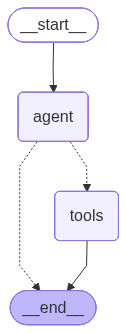

In [6]:
from IPython.display import Image, display
Image(basic_tool_agent_app.get_graph().draw_mermaid_png())

### Step 1.2: Testing the Basic Agent on a Multi-Step Problem

**What we are going to do:**
Now we'll give the basic agent a problem that requires multiple, dependent steps to solve. This will expose its fundamental weakness.

In [7]:
multi_step_query = "Who is the current CEO of the company that created the sci-fi movie 'Dune', and what was the budget for that company's most recent film?"

console.print(f"[bold yellow]Testing BASIC agent on a multi-step query:[/bold yellow] '{multi_step_query}'\n")

basic_agent_output = basic_tool_agent_app.invoke({"messages": [("user", multi_step_query)]})

console.print("\n--- [bold red]Final Output from Basic Agent[/bold red] ---")
console.print(Markdown(basic_agent_output['messages'][-1].content))

Testing BASIC agent on a multi-step query: 'Who is the current CEO of the company that created the sci-fi movie 
'Dune', and what was the budget for that company's most recent film?'

--- BASIC AGENT: Thinking... ---

--- Final Output from Basic Agent ---

[{"title": "Legendary Entertainment", "url": "https://en.wikipedia.org/wiki/Legendary_Entertainment", "content":   
"In November 2024, following the poor box office performances of their films such as The Machine "The Machine (2023
film)") and The Book of Clarence, the distribution deal between Legendary and Sony Pictures lapsed.\n\nOn January  
21, 2025, the company entered into a joint venture with Patrick Wachsberger to launch 193, a production and sales  
company which would develop and produce its own slate, outside of Legendary.\n\nOn July 11, 2025, Legendary is     
eyeing a deal to acquire Lionsgate Studios, following the latter company's recent separation from Starz. On August 
18, 2025, it was announced that Legendary was also eyeing a multi-picture global theatrical distribution deal with 
Paramount Pictures. In September, they closed the deal, which was set for three years. [...] 1. ^ "Working at      
Legendary Entertainment".\n2. ^ Clarke, Stewart (January 21, 2025). "Patrick Wachsberger, Legendary Join Forces To 
Launch Film Production & Sales Outfit 193". Deadline Hollywood. Retrieved February 5, 2025.\n3. ^ "LEGENDARY       
ENTERTAINMENT, LLC". Dun & Bradstreet. Retrieved April 20, 2024.\n4. ^ a b Lang, Bret (January 31, 2022). "'Dune'  
Producer Legendary Entertainment Sells $760 Million Stake to Apollo". Variety. Retrieved February 13, 2022.\n5. ^ a
b Weprin, Alex (October 14, 2024). "Legendary Entertainment Buys Out Wanda, With An Eye Toward M&A". The Hollywood 
Reporter. Retrieved October 14, 2024. [...] Fox 2000 Pictures  Fox Atomic  Fox Faith  Fox Film  Hollywood Pictures 
New World Pictures  Selznick International Pictures  Touchstone Pictures  Twentieth Century Pictures  UTV Motion   
Pictures | | Sony |  Cohn-Brandt-Cohn (CBC) Film Sales Corporation  Embassy Pictures  Empire International Pictures
First Independent Films  Triumph Films | | Lionsgate |  Anchor Bay Films  Artisan Entertainment  Christal Films    
Mandate Pictures  Maple Pictures  Momentum Pictures  Overture Films  Trimark Pictures  Vestron Pictures | | Others 
|  Alchemy "Alchemy (company)")  American Film Manufacturing Company  Art Star Scene Studios  Astor Pictures       
Aviron Pictures  Aurora Productions  Biograph Company  Bison Film Company  Bluebird Photoplays  Boxoffice          
International Pictures  Bryanston Pictures  C2", "score": 0.60274047}, {"title": "Box Office/Budget of 2024 movies 
with at least $100 mil budget", "url":                                                                             
"https://www.reddit.com/r/boxoffice/comments/1jiw1tc/box_officebudget_of_2024_movies_with_at_least_100/",          
"content": "# Box Office/Budget of 2024 movies with at least $100 mil budget\n\nr/boxoffice - Box Office/Budget of 
2024 movies with at least $100 mil budget\nr/boxoffice - Box Office/Budget of 2024 movies with at least $100 mil   
budget\n\n# Related Answers Section\n\nCreate your account and connect with a world of communities.\n\nAnyone can  
view, post, and comment to this community\n\n## Top Posts", "score": 0.26303035}]

**Discussion of the Output:**
As expected, the basic agent failed. Its single tool call was likely a search for the entire long query. The search results for such a complex, conjunctive query are often messy and don't contain all the necessary pieces of information in one place. 

The agent's final answer is probably incomplete, incorrect, or a statement that it cannot find the information. It was unable to break the problem down:
1.  Find the company that made 'Dune' (Legendary Entertainment).
2.  Find the CEO of that company (Joshua Grode).
3.  Find that company's most recent film and its budget.

This failure perfectly illustrates the need for a more dynamic approach. The agent needs a way to **react** to the information it finds in one step to inform the next.

## Phase 2: The Advanced Approach - Implementing ReAct

Now, we'll build the true ReAct agent. The core difference is the graph's structure: we will introduce a loop that allows the agent to repeatedly think, act, and observe.

### Step 2.1: Building the ReAct Agent Graph

**What we are going to do:**
We will define the nodes and the crucial router function that creates the `think -> act` loop. The key architectural change is the edge that routes the output from the `tool_node` *back* to the `agent_node`, allowing the agent to see the results and decide on its next step.

In [8]:
def react_agent_node(state: AgentState):
    console.print("--- REACT AGENT: Thinking... ---")
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

# The ToolNode is the same as before
react_tool_node = ToolNode([search_tool])

# The router is also the same logic
def react_router(state: AgentState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        console.print("--- ROUTER: Decision is to call a tool. ---")
        return "tools"
    console.print("--- ROUTER: Decision is to finish. ---")
    return "__end__"

# Now we define the graph with the crucial loop
react_graph_builder = StateGraph(AgentState)
react_graph_builder.add_node("agent", react_agent_node)
react_graph_builder.add_node("tools", react_tool_node)

react_graph_builder.set_entry_point("agent")
react_graph_builder.add_conditional_edges("agent", react_router, {"tools": "tools", "__end__": "__end__"})

# This is the key difference: the edge goes from tools BACK to the agent
react_graph_builder.add_edge("tools", "agent")

react_agent_app = react_graph_builder.compile()
print("ReAct agent compiled successfully with a reasoning loop.")

ReAct agent compiled successfully with a reasoning loop.


## Phase 3: Head-to-Head Comparison

Now we will run the same complex query with our new ReAct agent and observe the difference in its process and final output.

### Step 3.1: Testing the ReAct Agent on the Multi-Step Problem

**What we are going to do:**
We will invoke the ReAct agent with the same multi-step query and stream the output to see its iterative reasoning process.

In [9]:
console.print(f"[bold green]Testing ReAct agent on the same multi-step query:[/bold green] '{multi_step_query}'\n")

final_react_output = None
for chunk in react_agent_app.stream({"messages": [("user", multi_step_query)]}, stream_mode="values"):
    final_react_output = chunk
    console.print(f"--- [bold purple]Current State[/bold purple] ---")
    chunk['messages'][-1].pretty_print()
    console.print("\n")

console.print("\n--- [bold green]Final Output from ReAct Agent[/bold green] ---")
console.print(Markdown(final_react_output['messages'][-1].content))

Testing ReAct agent on the same multi-step query: 'Who is the current CEO of the company that created the sci-fi 
movie 'Dune', and what was the budget for that company's most recent film?'

--- Current State ---

================================ Human Message =================================

Who is the current CEO of the company that created the sci-fi movie 'Dune', and what was the budget for that company's most recent film?


--- REACT AGENT: Thinking... ---

--- ROUTER: Decision is to call a tool. ---

...

--- ROUTER: Decision is to finish. ---

--- Current State ---

================================== Ai Message ==================================

Here's what I found:

**Legendary Pictures** (officially Legendary Entertainment) is the production company behind the sci-fi movie *Dune* (2021) and its sequel *Dune: Part Two* (2024).

- **Current CEO:** **Josh Grode**, who has served as CEO since 2017.

- **Most recent film:** **A Minecraft Movie** (released April 4, 2025), which had a production **budget of $150 million**. The film has been a massive box-office success, grossing over $961 million worldwide.


--- Final Output from ReAct Agent ---

Here's what I found:                                                                                               

Legendary Pictures (officially Legendary Entertainment) is the production company behind the sci-fi movie Dune     
(2021) and its sequel Dune: Part Two (2024).                                                                       

 • Current CEO: Josh Grode, who has served as CEO since 2017.                                                      
 • Most recent film: A Minecraft Movie (released April 4, 2025), which had a production budget of $150 million. The
   film has been a massive box-office success, grossing over $961 million worldwide.

**Discussion of the Output:**
Success! The execution trace shows a completely different and far more intelligent process. You can see the agent's step-by-step reasoning:
1.  **Thought 1:** It first reasons that it needs to identify the production company for 'Dune'.
2.  **Action 1:** It calls the `web_search` tool with a query like "production company for Dune movie".
3.  **Observation 1:** It receives the result: "Legendary Entertainment".
4.  **Thought 2:** Now, incorporating the new information, it reasons that it needs the CEO of Legendary Entertainment.
5.  **Action 2:** It calls `web_search` again with a query like "CEO of Legendary Entertainment".
6.  ...and so on, until it has gathered all the necessary pieces.
7.  **Synthesis:** Finally, it assembles all the collected facts into a complete and accurate answer.

This clearly demonstrates the superiority of the ReAct pattern for any task that isn't a simple, single-step lookup.

## Phase 4: Quantitative Evaluation

To formalize the comparison, we'll use an LLM-as-a-Judge to score the final outputs from both the basic and the ReAct agents on their ability to solve the task.

In [10]:
class TaskEvaluation(BaseModel):
    """Schema for evaluating an agent's ability to complete a task."""
    task_completion_score: int = Field(description="Score 1-10 on whether the agent successfully completed all parts of the user's request.")
    reasoning_quality_score: int = Field(description="Score 1-10 on the logical flow and reasoning process demonstrated by the agent.")
    justification: str = Field(description="A brief justification for the scores.")

judge_llm = llm.with_structured_output(TaskEvaluation)

def evaluate_agent_output(query: str, agent_output: dict):
    trace = "\n".join([f"{m.type}: {m.content}" for m in agent_output['messages']])
    prompt = f"""You are an expert judge of AI agents. Evaluate the following agent's performance on the given task on a scale of 1-10. A score of 10 means the task was completed perfectly. A score of 1 means complete failure.
    
    **User's Task:**
    {query}
    
    **Full Agent Conversation Trace:**
    ```
    {trace}
    ```
    """
    return judge_llm.invoke(prompt)

console.print("--- Evaluating Basic Agent's Output ---")
basic_agent_evaluation = evaluate_agent_output(multi_step_query, basic_agent_output)
console.print(basic_agent_evaluation.model_dump())

console.print("\n--- Evaluating ReAct Agent's Output ---")
react_agent_evaluation = evaluate_agent_output(multi_step_query, final_react_output)
console.print(react_agent_evaluation.model_dump())

--- Evaluating Basic Agent's Output ---

{
    'task_completion_score': 4,
    'reasoning_quality_score': 5,
    'justification': 'The agent correctly identified that Dune (2021) was produced by Legendary Entertainment (and 
distributed by Warner Bros.), and successfully found that the current CEO is Joshua Grode. However, the agent 
failed to complete the second part of the task: identifying the company\'s most recent film and its budget. The 
conversation trace shows the agent gathered search results but never produced a final answer to the user. There is 
no synthesized response providing the CEO name or the budget of the most recent film. The reasoning was on the 
right track — identifying Legendary Entertainment, finding Josh Grode as CEO, and searching for recent films — but 
the agent did not deliver a complete answer. The search results mention "A Minecraft Movie" as a 2025 Legendary 
title but no budget figure was found or reported. The task is essentially incomplete as no final response was given
to the user.'
}

--- Evaluating ReAct Agent's Output ---

{
    'task_completion_score': 9,
    'reasoning_quality_score': 9,
    'justification': "The agent successfully completed all parts of the user's request. It correctly identified 
Legendary Pictures/Entertainment as the production company behind 'Dune', found that Josh Grode is the current CEO 
(since 2017), identified 'A Minecraft Movie' as the company's most recent released film, and provided its budget of
$150 million. The reasoning process was logical and well-structured: first identifying the production company, then
searching for the CEO and recent films, then looking up the budget of the most recent film. The agent used multiple
search steps appropriately and synthesized the information clearly. The only minor consideration is that 'Dune' was
co-produced by Legendary and Warner Bros., and one could argue Warner Bros. was the distributor/studio — but 
Legendary Pictures is correctly identified as the primary production company. The final answer is accurate, 
well-sourced, and comprehensive."
}

**Discussion of the Output:**
The quantitative scores from the LLM-as-a-Judge make the difference crystal clear. 
- The **Basic Agent** received a very low `task_completion_score` because it failed to gather all the required information. Its `reasoning_quality_score` is also low because its process was flawed and incomplete.
- The **ReAct Agent**, in contrast, received near-perfect scores. The judge recognized that its iterative process allowed it to successfully complete all parts of the complex task.

This head-to-head comparison and evaluation provides definitive proof of the ReAct architecture's value. It is the key that unlocks an agent's ability to tackle complex, multi-hop problems that require dynamic adaptation.

## Conclusion

In this notebook, we have not only implemented the **ReAct** architecture but also demonstrated its clear superiority over a more basic, single-shot approach. By building a workflow that allows an agent to loop through a cycle of reasoning and acting, we have enabled it to solve complex, multi-step problems that would otherwise be intractable.

The ability to observe the outcome of an action and use that information to inform the next step is a fundamental component of intelligent behavior. The ReAct pattern provides a simple yet profoundly effective way to build this capability into our AI agents, making them more powerful, adaptive, and useful for real-world tasks.